# Parkinson’s Cognitive Monitoring System Using HRV, SVM & Linear Regression - E0422002 & E0422003

In [43]:
from PIL import Image  
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("Amudha Selvaraj ECG 2.png")  
image.show()

image_array = np.array(image)
print(image_array.shape)

(3388, 4416, 4)


(3388, 4416, 4)


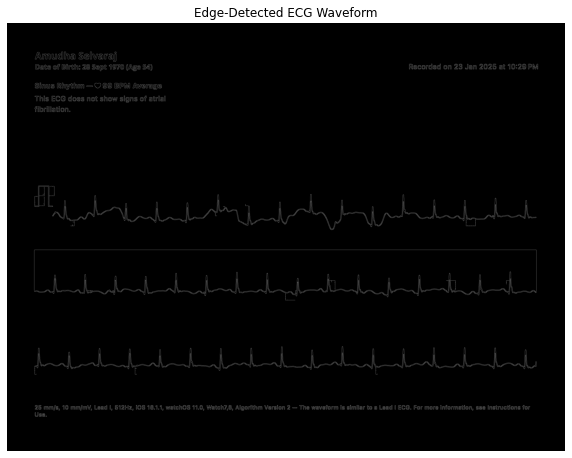

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("Amudha Selvaraj ECG 2.png")

image.show()

image_array = np.array(image)
print(image_array.shape)  

if image_array.shape[-1] == 4: 
    image_array = cv2.cvtColor(image_array, cv2.COLOR_RGBA2BGR)

gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

plt.figure(figsize=(10, 8))
plt.title("Edge-Detected ECG Waveform")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

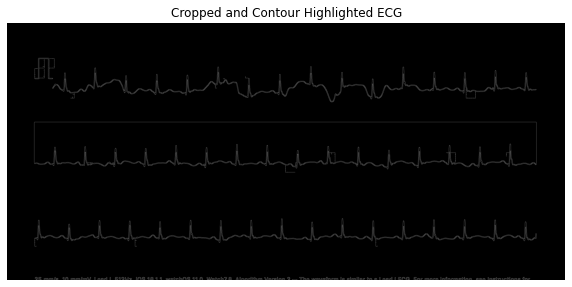

In [7]:
height, width = edges.shape
roi = edges[int(height * 0.3):int(height * 0.9), :] 

contours, _ = cv2.findContours(roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_image = np.zeros_like(roi)
cv2.drawContours(contour_image, contours, -1, (255), 1)

plt.figure(figsize=(10, 6))
plt.title("Cropped and Contour Highlighted ECG")
plt.imshow(contour_image, cmap='gray')
plt.axis('off')
plt.show()

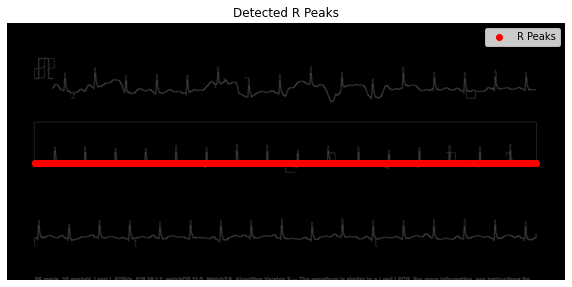

array([0.28, 0.04, 0.08, ..., 0.04, 0.08, 0.2 ])

In [8]:
y_coords, x_coords = np.where(contour_image > 0)

peak_indices = []
for i in range(0, len(x_coords), 10):  
    cluster = x_coords[i:i+10]
    if len(cluster) > 0:
        peak_indices.append(np.median(cluster))

peak_indices = np.array(sorted(set(map(int, peak_indices))))

plt.figure(figsize=(10, 6))
plt.imshow(contour_image, cmap='gray')
plt.scatter(peak_indices, [np.median(y_coords)] * len(peak_indices), color='red', label='R Peaks', zorder=5)
plt.title("Detected R Peaks")
plt.legend()
plt.axis('off')
plt.show()

rr_intervals_pixels = np.diff(peak_indices)

rr_intervals_seconds = rr_intervals_pixels * 0.04

rr_intervals_seconds

In [9]:
import pandas as pd

rr_intervals_df = pd.DataFrame(rr_intervals_seconds, columns=["R-R Interval (seconds)"])

rr_intervals_df.to_csv("rr_intervalsHRV.csv", index=False)

print("R-R intervals saved to rr_intervalsHRV.csv")


R-R intervals saved to rr_intervalsHRV.csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import iqr
from sklearn.preprocessing import StandardScaler

In [11]:
data = pd.read_csv('rr_intervals.csv')
rr_intervals = data['R-R Interval (seconds)'].values

In [39]:
if data.isnull().sum().any():
    print("Missing values detected. Handling missing values.")
    data = data.dropna() 

outliers = rr_intervals[np.abs(rr_intervals - np.mean(rr_intervals)) > 3 * np.std(rr_intervals)]
print(f"Outliers: {outliers}")

Outliers: [0.28 0.2  0.16 0.16 0.16 0.16 0.16 0.16 0.16 0.16 0.16 0.16 0.16 0.2
 0.16 0.2  0.16 0.16 0.16 0.2  0.16 0.16 0.16 0.16 0.16 0.16 0.16 0.16
 0.16 0.2  0.16 0.16 0.2  0.16 0.16 0.16 0.24 0.16 0.2  0.2  0.16 0.2
 0.16 0.16 0.16 0.16 0.16 0.16 0.2  0.16 0.16 0.2  0.16 0.16 0.2 ]


In [40]:
sdnn = np.std(rr_intervals)
print(f"SDNN: {sdnn}")

SDNN: 0.02722116873659457


In [41]:
diffs = np.diff(rr_intervals)
rmssd = np.sqrt(np.mean(diffs**2))
print(f"RMSSD: {rmssd}")

RMSSD: 0.038291824805413745


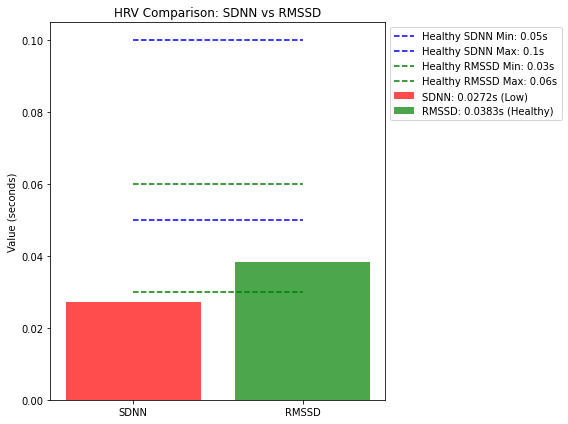

In [43]:
healthy_sdnn_range = (0.05, 0.1)  # Healthy SDNN range (50 ms to 100 ms)

healthy_rmssd_range = (0.03, 0.06)  # Healthy RMSSD range (30 ms to 60 ms)

plt.figure(figsize=(8, 6))

plt.bar('SDNN', sdnn, color='red', alpha=0.7, label=f'SDNN: {sdnn:.4f}s (Low)')

plt.bar('RMSSD', rmssd, color='green', alpha=0.7, label=f'RMSSD: {rmssd:.4f}s (Healthy)')

plt.plot(['SDNN', 'RMSSD'], [healthy_sdnn_range[0], healthy_sdnn_range[0]], color='blue', linestyle='--', label=f'Healthy SDNN Min: {healthy_sdnn_range[0]}s')
plt.plot(['SDNN', 'RMSSD'], [healthy_sdnn_range[1], healthy_sdnn_range[1]], color='blue', linestyle='--', label=f'Healthy SDNN Max: {healthy_sdnn_range[1]}s')

plt.plot(['SDNN', 'RMSSD'], [healthy_rmssd_range[0], healthy_rmssd_range[0]], color='green', linestyle='--', label=f'Healthy RMSSD Min: {healthy_rmssd_range[0]}s')
plt.plot(['SDNN', 'RMSSD'], [healthy_rmssd_range[1], healthy_rmssd_range[1]], color='green', linestyle='--', label=f'Healthy RMSSD Max: {healthy_rmssd_range[1]}s')

plt.title('HRV Comparison: SDNN vs RMSSD')
plt.ylabel('Value (seconds)')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [18]:
def classify_cognitive_state(sdnn, rmssd):
    if sdnn > 40 and rmssd > 25:
        return "Healthy", 1  # Healthy state, binary 1
    elif 30 <= sdnn <= 40 and 17 <= rmssd <= 25:
        return "Mild Cognitive Impairment", 2  # Optional: can add binary for "Mild Cognitive Impairment" if needed
    else:
        return "Declining Cognitive Function", 0  # Declining state, binary 0

sdnn_value = 0.02722116873659457  
rmssd_value = 0.038291824805413745  

cognitive_state, binary_value = classify_cognitive_state(sdnn_value, rmssd_value)

print(f"Cognitive State Prediction: {binary_value}")
print(f"Result: {cognitive_state}")

Cognitive State Prediction: 0
Result: Declining Cognitive Function


# Hybrid SVM and Linear Regression With 20 Patient Data Points

In [39]:
import pandas as pd

file_path = "SDNN&RMSSD.csv"
df = pd.read_csv(file_path)

df.head()

,Person ID,SDNN (s),RMSSD (s),Cognitive State
0,1,0.0272,0.0383,1
1,2,0.0645,0.0562,0
2,3,0.0452,0.0427,1
3,4,0.0721,0.0493,0
4,5,0.0309,0.0378,1


SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


📉 Linear Regression Results:
Coefficient: 0.5071
Intercept: 0.0215
Mean Squared Error: 0.000011


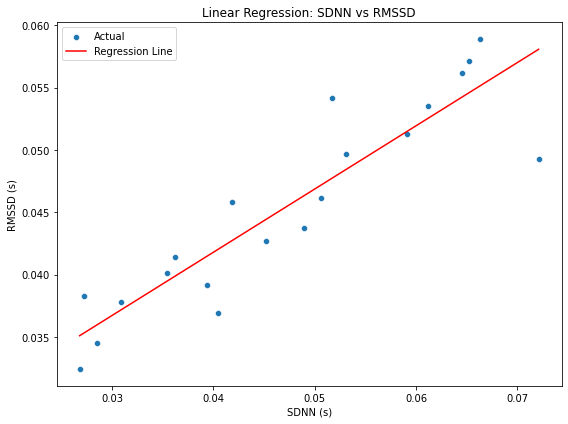

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("SDNN&RMSSD.csv")

# Features and target
X = df[['SDNN (s)', 'RMSSD (s)']]
y = df['Cognitive State']

# SVM Classification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred))

# Linear Regression (RMSSD from SDNN)
X_reg = df[['SDNN (s)']]
y_reg = df['RMSSD (s)']
reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)

df['Predicted RMSSD'] = reg_model.predict(X_reg)

print("\n📉 Linear Regression Results:")
print(f"Coefficient: {reg_model.coef_[0]:.4f}")
print(f"Intercept: {reg_model.intercept_:.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_reg, df['Predicted RMSSD']):.6f}")

# Plot regression
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SDNN (s)', y='RMSSD (s)', data=df, label='Actual')
sns.lineplot(x='SDNN (s)', y='Predicted RMSSD', data=df, color='red', label='Regression Line')
plt.title('Linear Regression: SDNN vs RMSSD')
plt.legend()
plt.tight_layout()
plt.show()